**1. DATA UNDERSTANDING**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**📌 Insight Dataset:** Data ini berisi 7.043 pelanggan sebuah perusahaan telco dengan 21 kolom, mencakup profil pelanggan (gender, status keluarga), layanan yang digunakan (internet, telepon, streaming), tipe kontrak & metode pembayaran, serta label target `Churn` (berhenti berlangganan atau tidak). Tujuan project ini: memprediksi `Churn` dari kolom-kolom lainnya.

**2. Data Cleaning & Preprocessing**

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['TotalCharges'].unique()[:10]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95']
Length: 10, dtype: str

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.shape

(7032, 21)

In [14]:
df.drop('customerID', axis=1, inplace=True, errors='ignore')

In [15]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [17]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

**📌 Ringkasan Cleaning:** Kolom `TotalCharges` awalnya bertipe teks karena ada 11 baris kosong, sehingga dikonversi ke angka dan baris kosongnya dibuang (tidak signifikan, <0.2% dari data). Kolom `customerID` dibuang karena hanya berupa ID unik, tidak punya nilai prediktif. Tidak ditemukan data duplikat.

**3. EDA**

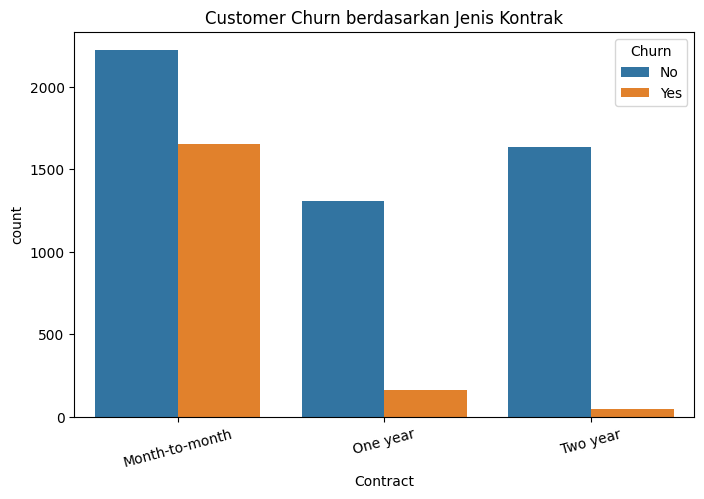

In [19]:
#1.Distribusi Contract vs Churn

plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Customer Churn berdasarkan Jenis Kontrak')

plt.xticks(rotation=15)

plt.show()

**📌 Insight:** Pelanggan dengan kontrak **month-to-month** jauh lebih banyak yang churn dibanding kontrak 1 atau 2 tahun. Masuk akal karena kontrak bulanan tidak ada komitmen jangka panjang — pelanggan bisa berhenti kapan saja.

<Axes: xlabel='tenure', ylabel='Count'>

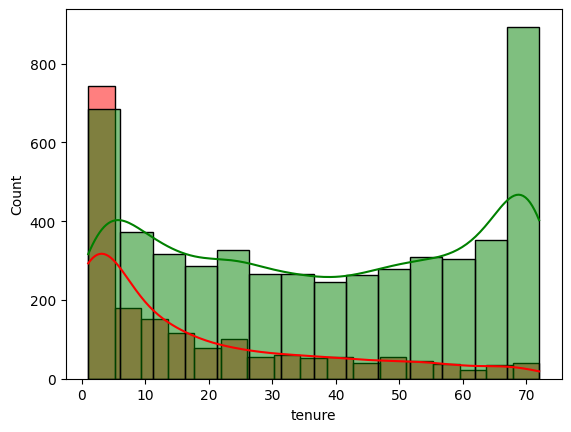

In [20]:
# 2.Distribusi Tenure berdasarkan Customer Churn
sns.histplot(df[df['Churn']=='Yes']['tenure'], kde=True, color='red', label='Churn')
sns.histplot(df[df['Churn']=='No']['tenure'], kde=True, color='green', label='No Churn')

**📌 Insight:** Pelanggan yang churn cenderung memiliki `tenure` (lama berlangganan) yang rendah — banyak yang berhenti di beberapa bulan pertama. Pelanggan yang sudah lama berlangganan jauh lebih jarang churn.

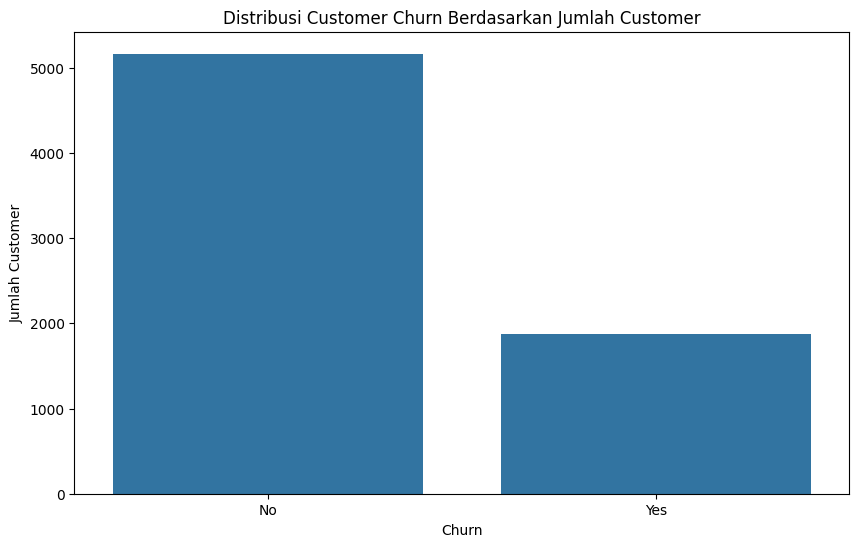

In [21]:
#3. Distribusi Target Churn

plt.figure(figsize=(10,6))
sns.countplot(x='Churn', data=df)

plt.title('Distribusi Customer Churn Berdasarkan Jumlah Customer')
plt.xlabel('Churn')
plt.ylabel('Jumlah Customer')

plt.show()

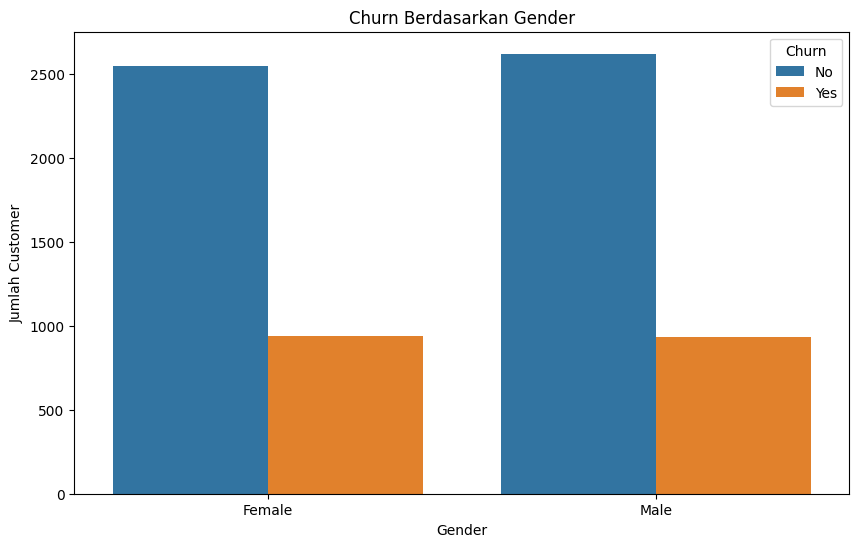

In [22]:
#4. Churn Berdasarkan Gender

plt.figure(figsize=(10,6))
sns.countplot(x='gender', hue='Churn', data=df)

plt.title('Churn Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Customer')

plt.show()

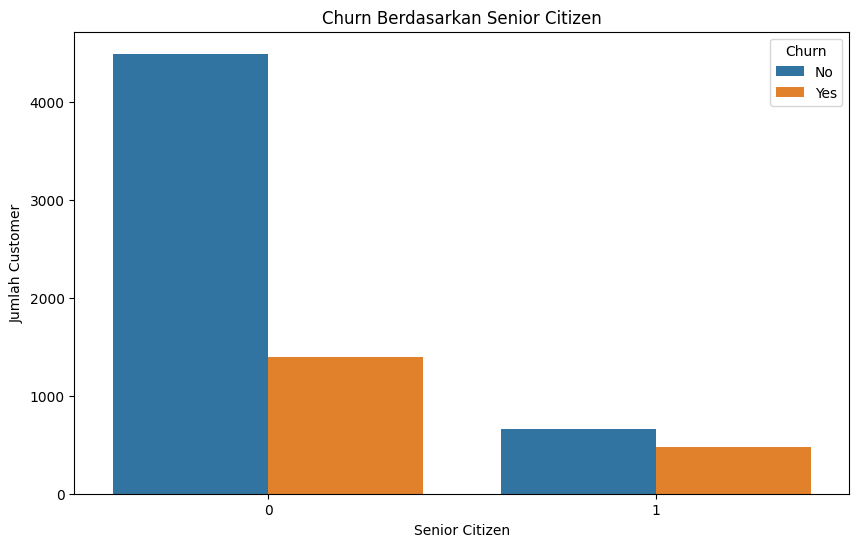

In [23]:
#5. Churn Berdasarkan Senior Citizen

plt.figure(figsize=(10,6))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title('Churn Berdasarkan Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Jumlah Customer')

plt.show()

**📌 Insight Demografi:** Dari sisi gender, proporsi churn antara laki-laki dan perempuan hampir sama (gender bukan faktor pembeda yang kuat). Sementara itu, pelanggan **senior citizen** punya proporsi churn yang lebih tinggi dibanding yang bukan senior.

4. Encoding & Feature Engineering

In [24]:
# Encoding Kategori (semua kolom kategori menjadi angka 0/1)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [25]:
# Memisahkan Feature dan Target
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [26]:
# Cek Distribusi Target
y.value_counts()

Churn_Yes
False    5163
True     1869
Name: count, dtype: int64

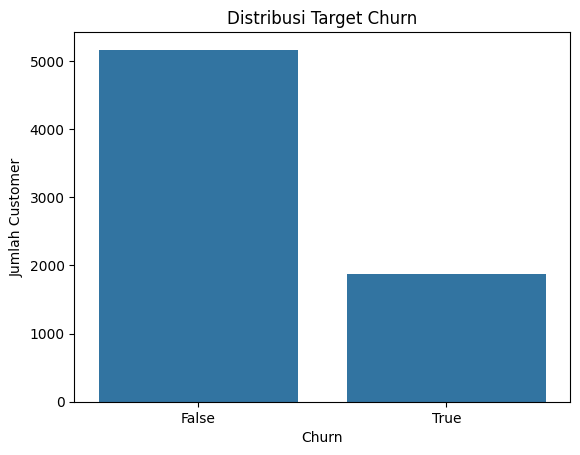

In [27]:
sns.countplot(x=y)

plt.title('Distribusi Target Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Customer')

plt.show()

**📌 Catatan Class Imbalance:** Target `Churn` tidak seimbang — sekitar 73% "No" vs 27% "Yes". Ini bisa membuat model cenderung "malas" memprediksi kelas minoritas (Churn). Nanti di bagian modeling, akan dicoba satu penyesuaian sederhana (`class_weight='balanced'`) untuk melihat pengaruhnya terhadap kemampuan model mendeteksi pelanggan yang benar-benar churn.

In [28]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit hanya pada data training
X_train = scaler.fit_transform(X_train)

# Data testing hanya di-transform
X_test = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42)

logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
X_scaled = pd.DataFrame(
    X_train,
    columns=X.columns
)

X_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.439319,1.321816,0.981556,1.659900,0.996274,1.028312,1.529143,0.327542,-0.327542,1.165543,...,-0.522962,-0.797873,-0.522962,-0.799964,-0.515787,1.772603,-1.21303,1.905159,-0.716177,-0.539468
1,-0.439319,-0.267410,-0.971546,-0.562252,0.996274,-0.972468,-0.653961,-3.053048,3.053048,-0.857969,...,-0.522962,-0.797873,-0.522962,-0.799964,-0.515787,-0.564142,-1.21303,-0.524891,1.396302,-0.539468
2,-0.439319,1.444064,0.837066,1.756104,-1.003740,1.028312,-0.653961,0.327542,-0.327542,1.165543,...,-0.522962,-0.797873,-0.522962,-0.799964,-0.515787,1.772603,-1.21303,1.905159,-0.716177,-0.539468
3,-0.439319,-1.204646,0.641092,-0.908326,0.996274,-0.972468,-0.653961,0.327542,-0.327542,-0.857969,...,-0.522962,-0.797873,-0.522962,1.250057,-0.515787,-0.564142,-1.21303,-0.524891,1.396302,-0.539468
4,-0.439319,0.669826,-0.808787,-0.101561,-1.003740,1.028312,-0.653961,-3.053048,3.053048,-0.857969,...,-0.522962,1.253332,-0.522962,-0.799964,-0.515787,-0.564142,-1.21303,-0.524891,-0.716177,-0.539468


In [32]:
# Cek ukuran data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


**5. Modeling**

In [33]:
# Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred[:10]

array([False,  True, False, False, False, False, False, False,  True,
       False])

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



**📌 Catatan:** Recall untuk kelas "Churn" (57%) masih lebih rendah dari precision-nya (65%). Artinya dari semua pelanggan yang sebenarnya akan churn, model ini baru berhasil menangkap sekitar setengahnya. Untuk kasus bisnis seperti churn, **recall biasanya lebih penting** — lebih baik salah curiga ke pelanggan yang sebenarnya tidak akan churn (false positive), daripada gagal mendeteksi pelanggan yang benar-benar akan pergi (false negative), karena biaya kehilangan pelanggan biasanya lebih mahal daripada biaya kirim promo retensi yang "salah sasaran".

In [35]:
# DecisionTree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.47      0.46      0.46       374

    accuracy                           0.72      1407
   macro avg       0.64      0.63      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [36]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

hasil_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision (Churn)': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall (Churn)': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score (Churn)': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

hasil_model

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065
1,Decision Tree,0.716418,0.466125,0.459893,0.462988
2,Random Forest,0.788202,0.623377,0.513369,0.563050


**📌 Coba Perbaikan Sederhana: `class_weight='balanced'`**

Berdasarkan catatan class imbalance sebelumnya, dicoba melatih ulang Logistic Regression dengan parameter `class_weight='balanced'`. Parameter ini membuat model "memberi bobot lebih besar" pada kelas minoritas (Churn) saat belajar, tanpa perlu mengubah data sama sekali — jadi mudah diterapkan dan dijelaskan.

In [38]:
# Logistic Regression dengan class_weight='balanced'
logreg_balanced = LogisticRegression(random_state=42, class_weight='balanced')
logreg_balanced.fit(X_train, y_train)

y_pred_balanced = logreg_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.91      0.70      0.79      1033
        True       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



**📌 Perbandingan:** Dengan `class_weight='balanced'`, recall kelas Churn biasanya naik cukup signifikan (model jadi lebih "peka" mendeteksi pelanggan yang akan churn), tapi precision-nya turun (lebih banyak juga pelanggan yang sebenarnya tidak churn ikut ditandai berisiko). Ini adalah **trade-off yang wajar** dalam klasifikasi — pilihan mana yang dipakai tergantung prioritas bisnis: kalau tim retensi punya budget besar untuk follow-up, model versi `balanced` lebih disukai karena minim pelanggan churn yang terlewat.

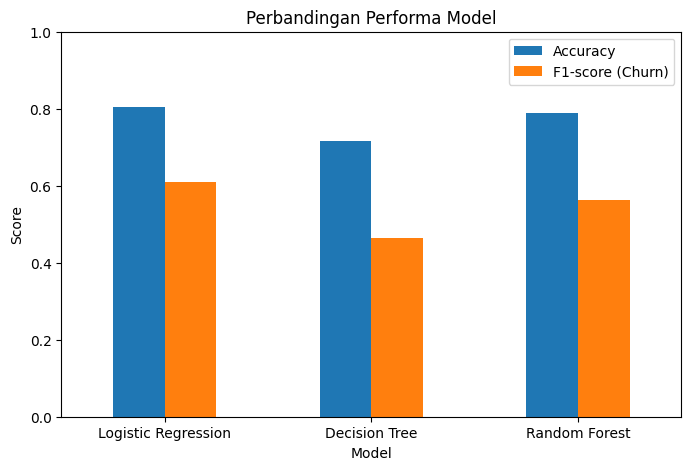

In [39]:
import matplotlib.pyplot as plt

hasil_model.set_index('Model')[['Accuracy', 'F1-score (Churn)']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

[[916 117]
 [159 215]]


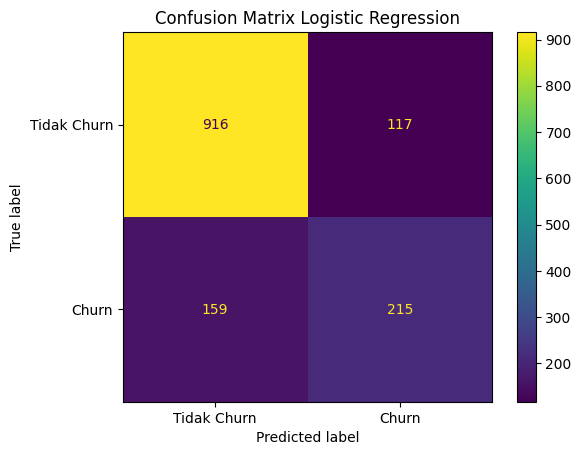

In [40]:
# Confusion Matrix Log Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Churn', 'Churn']
)

disp.plot()

plt.title('Confusion Matrix Logistic Regression')
plt.show()

ROC-AUC Score: 0.836


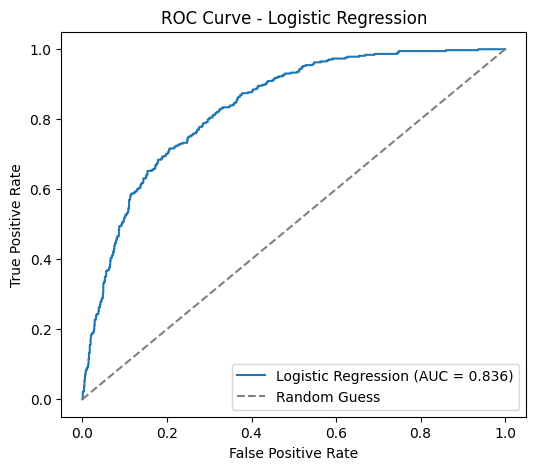

In [41]:
# ROC-AUC — mengukur seberapa baik model membedakan pelanggan churn vs tidak,
# di semua kemungkinan threshold (bukan cuma threshold 0.5)
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = logreg.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc_score:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

**📌 Interpretasi ROC-AUC:** Skor ROC-AUC berkisar 0–1, di mana 0.5 berarti model menebak secara acak (seperti lempar koin) dan 1.0 berarti model sempurna. Skor di atas ~0.8 pada kasus ini menunjukkan model cukup baik dalam membedakan pelanggan yang berpotensi churn dari yang tidak, terlepas dari threshold yang dipakai.

In [42]:
#Analisis Koefision Logistic Regression
# Mengambil nilai koefisien model
koefisien = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
})

# Mengurutkan berdasarkan pengaruh terbesar
koefisien['Absolute'] = abs(koefisien['Coefficient'])

koefisien = koefisien.sort_values(
    by='Absolute',
    ascending=False
)

koefisien

,Feature,Coefficient,Absolute
1,tenure,-1.347613,1.347613
2,MonthlyCharges,-0.851551,0.851551
10,InternetService_Fiber optic,0.727745,0.727745
3,TotalCharges,0.639028,0.639028
25,Contract_Two year,-0.602591,0.602591
24,Contract_One year,-0.310898,0.310898
21,StreamingTV_Yes,0.249702,0.249702
23,StreamingMovies_Yes,0.236368,0.236368
9,MultipleLines_Yes,0.214359,0.214359
28,PaymentMethod_Electronic check,0.181473,0.181473


**Model Interpretation**

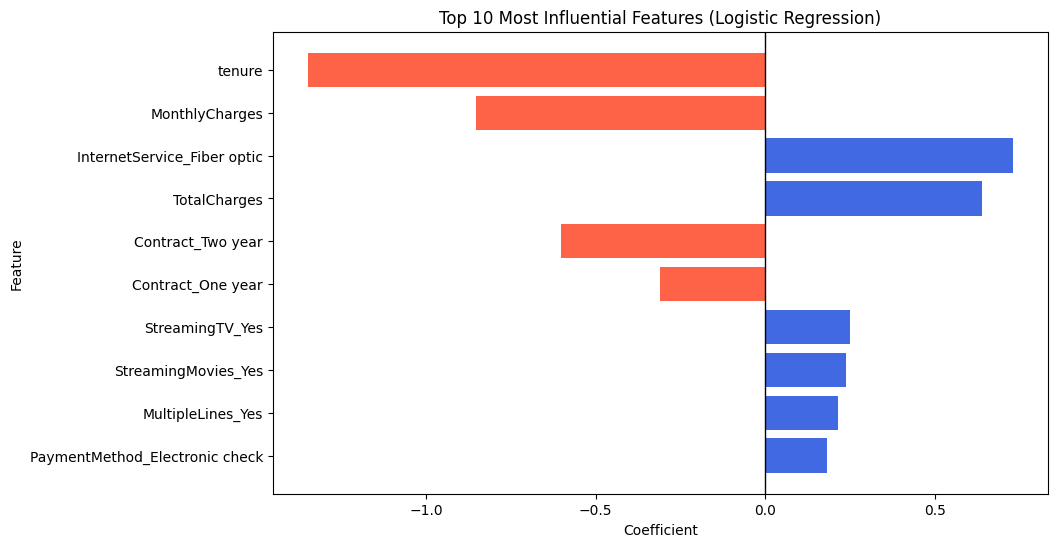

In [43]:
# Membuat DataFrame koefisien
feature_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
})

# Urutkan berdasarkan nilai absolut koefisien
feature_coef = feature_coef.reindex(
    feature_coef['Coefficient'].abs().sort_values(ascending=False).index
)

# Ambil 10 fitur paling berpengaruh
top10 = feature_coef.head(10)

# Warna berdasarkan arah koefisien
colors = ['royalblue' if x > 0 else 'tomato' for x in top10['Coefficient']]

# Plot
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Coefficient'], color=colors)

plt.gca().invert_yaxis()
plt.title('Top 10 Most Influential Features (Logistic Regression)')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=1)

plt.show()

**📌 Ringkasan Faktor Pendorong Churn:** Warna biru (koefisien positif) berarti fitur tersebut **meningkatkan** kemungkinan churn, warna merah (koefisien negatif) berarti **menurunkan** kemungkinan churn. Dari grafik di atas, faktor-faktor yang paling mendorong pelanggan berhenti umumnya berkaitan dengan: tipe kontrak bulanan (bukan tahunan), belum lama berlangganan (`tenure` rendah), dan penggunaan layanan internet fiber optic. Sebaliknya, kontrak jangka panjang dan `tenure` yang tinggi paling menurunkan risiko churn.

# Predict New Customer

In [44]:
sample_index = y_test.index[0]

# Lihat data asli pelanggan
df.loc[[sample_index]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35,No


In [45]:
pos_index = y_test.index.get_loc(sample_index)
new_customer = X_test[pos_index].reshape(1, -1)

prediction = logreg.predict(new_customer)
probability = logreg.predict_proba(new_customer)

if prediction[0] == 1:
    print("Prediction : Customer will Churn")
else:
    print("Prediction : Customer will Not Churn")

print(f"Probability of Churn : {probability[0][1]*100:.2f}%")

Prediction : Customer will Not Churn
Probability of Churn : 1.71%


## 6. Kesimpulan & Rekomendasi Bisnis

**Model terbaik:** Logistic Regression (accuracy ~80%, ROC-AUC ~0.8+) dipilih sebagai model utama karena performanya kompetitif dibanding Decision Tree dan Random Forest, sekaligus **paling mudah diinterpretasi** — penting untuk menjelaskan hasilnya ke tim non-teknis.

**Temuan utama:**
- Pelanggan dengan **kontrak bulanan (month-to-month)** dan **tenure rendah** (baru berlangganan) adalah kelompok dengan risiko churn tertinggi.
- Pelanggan **senior citizen** juga menunjukkan risiko churn yang lebih tinggi.
- Pengguna layanan **internet fiber optic** cenderung lebih sering churn dibanding pengguna DSL — kemungkinan terkait harga atau ekspektasi layanan.

**Rekomendasi bisnis:**
1. Prioritaskan program retensi (diskon, penawaran khusus) untuk pelanggan baru dengan kontrak bulanan di 3-6 bulan pertama, karena periode ini paling rawan churn.
2. Dorong migrasi dari kontrak bulanan ke kontrak tahunan lewat insentif, karena kontrak panjang terbukti menurunkan churn secara signifikan.
3. Tinjau ulang pengalaman pelanggan fiber optic (harga, kualitas layanan) karena churn-nya lebih tinggi dari ekspektasi.

**Keterbatasan & pengembangan lanjutan:**
- Model belum di-tuning (masih pakai parameter default) — hyperparameter tuning berpotensi meningkatkan performa lebih jauh.
- Class imbalance baru ditangani dengan `class_weight='balanced'` sebagai percobaan awal; teknik lain seperti SMOTE bisa dicoba untuk perbandingan.
- Dataset merupakan snapshot satu waktu; performa di data real-time perlu dipantau ulang secara berkala (model bisa "usang" seiring waktu).

save

In [46]:
import joblib

joblib.dump(logreg, "logistic_regression_churn.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

## 7. Deployment (Contoh Sederhana)

Supaya model ini tidak cuma "hidup" di notebook, model dan scaler yang sudah disimpan (`logistic_regression_churn.pkl` dan `scaler.pkl`) dipakai untuk membangun aplikasi web sederhana dengan **Streamlit**, tempat siapa pun bisa input data pelanggan lewat form dan langsung melihat prediksi churn-nya.

File aplikasinya (`app.py`) ada terpisah dari notebook ini. Cara menjalankannya:

```bash
pip install streamlit joblib pandas scikit-learn
streamlit run app.py
```

Aplikasi ini sengaja dibuat simpel (form input + tombol prediksi) — cukup untuk menunjukkan model bisa dipakai di luar notebook, tanpa perlu infrastruktur deployment yang rumit.

In [47]:
# Simpan juga daftar kolom fitur, supaya saat prediksi data baru (di app.py)
# kolom hasil encoding-nya bisa disamakan persis dengan yang dipakai saat training
joblib.dump(list(X.columns), "feature_columns.pkl")
print("Kolom fitur berhasil disimpan:", len(X.columns), "kolom")

Kolom fitur berhasil disimpan: 30 kolom
